<a href="https://colab.research.google.com/github/Himanshu0518/Sales-Analytics-Customer-Behavior-Dashboard/blob/main/notebooks/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
order_df=pd.read_csv('/content/Orders.csv',sep=';', on_bad_lines='skip')
order_df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Postal Code,Product ID,Sales,Quantity,Discount,Profit
0,1,CA-2022-152156,08/11/2022,11/11/2022,Second Class,CG-12520,Consumer,42420,FUR-BO-10001798,"261,96",2,0,"41,9136"
1,2,CA-2022-152156,08/11/2022,11/11/2022,Second Class,CG-12520,Consumer,42420,FUR-CH-10000454,"731,94",3,0,"219,582"


In [21]:
prod_df=pd.read_csv('/content/Products.csv',sep=';', on_bad_lines='skip', encoding='latin1')


In [19]:
cust_df=pd.read_csv('/content/Customers.csv',sep=';', on_bad_lines='skip', encoding='latin1')

In [20]:
cust_df.head(2)

,Customer ID,Customer Name
0,AA-10315,Alex Avila
1,AA-10375,Allen Armold


In [16]:
loc_df=pd.read_csv('/content/Location.csv',sep=';', on_bad_lines='skip')
loc_df.head()

,Postal Code,City,State,Region,Country/Region
0,76106.0,Fort Worth,Texas,Central,United States
1,53711.0,Madison,Wisconsin,Central,United States
2,68025.0,Fremont,Nebraska,Central,United States
3,77095.0,Houston,Texas,Central,United States
4,75080.0,Richardson,Texas,Central,United States


In [22]:
df = pd.merge(cust_df, order_df, on='Customer ID')
df = pd.merge(df, prod_df, on='Product ID')
df

,Customer ID,Customer Name,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Segment,Postal Code,Product ID,Sales,Quantity,Discount,Profit,Category,Sub-Category,Product Name
0,AA-10315,Alex Avila,1160,CA-2023-147039,29/06/2023,04/07/2023,Standard Class,Consumer,55407,OFF-AP-10000576,"362,94",3,0,"90,735",Office Supplies,Appliances,Belkin 7 Outlet SurgeMaster II
1,AA-10315,Alex Avila,1160,CA-2023-147039,29/06/2023,04/07/2023,Standard Class,Consumer,55407,OFF-AP-10000576,"362,94",3,0,"90,735",Office Supplies,Appliances,"Belkin 325VA UPS Surge Protector, 6'"
2,AA-10315,Alex Avila,1161,CA-2023-147039,29/06/2023,04/07/2023,Standard Class,Consumer,55407,OFF-BI-10004654,"11,54",2,0,"5,77",Office Supplies,Binders,Avery Binding System Hidden Tab Executive Styl...
3,AA-10315,Alex Avila,1161,CA-2023-147039,29/06/2023,04/07/2023,Standard Class,Consumer,55407,OFF-BI-10004654,"11,54",2,0,"5,77",Office Supplies,Binders,VariCap6 Expandable Binder
4,AA-10315,Alex Avila,1300,CA-2021-121391,04/10/2021,07/10/2021,First Class,Consumer,94109,OFF-ST-10001590,"26,96",2,0,"7,0096",Office Supplies,Storage,Tenex Personal Project File with Scoop Front D...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10326,ZD-21925,Zuschuss Donatelli,3815,CA-2022-152471,08/07/2022,08/07/2022,Same Day,Consumer,32216,TEC-PH-10002824,"823,96",5,"0,2","51,4975",Technology,Phones,Jabra SPEAK 410 Multidevice Speakerphone
10327,ZD-21925,Zuschuss Donatelli,3816,CA-2022-152471,08/07/2022,08/07/2022,Same Day,Consumer,32216,OFF-PA-10004965,"15,984",2,"0,2","4,995",Office Supplies,Paper,Xerox 1921
10328,ZD-21925,Zuschuss Donatelli,5898,CA-2022-167682,03/04/2022,09/04/2022,Standard Class,Consumer,47374,FUR-FU-10003799,"71,12",4,0,"22,0472",Furniture,Furnishings,"Seth Thomas 13 1/2"" Wall Clock"
10329,ZD-21925,Zuschuss Donatelli,5899,CA-2022-167682,03/04/2022,09/04/2022,Standard Class,Consumer,47374,TEC-PH-10000673,"259,96",4,0,"124,7808",Technology,Phones,Plantronics Voyager Pro HD - Bluetooth Headset


In [23]:
df.isnull().sum()

,0
Customer ID,0
Customer Name,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Segment,0
Postal Code,0
Product ID,0


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10331 entries, 0 to 10330
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Customer ID    10331 non-null  object
 1   Customer Name  10331 non-null  object
 2   Row ID         10331 non-null  int64 
 3   Order ID       10331 non-null  object
 4   Order Date     10331 non-null  object
 5   Ship Date      10331 non-null  object
 6   Ship Mode      10331 non-null  object
 7   Segment        10331 non-null  object
 8   Postal Code    10331 non-null  int64 
 9   Product ID     10331 non-null  object
 10  Sales          10331 non-null  object
 11  Quantity       10331 non-null  int64 
 12  Discount       10331 non-null  object
 13  Profit         10331 non-null  object
 14  Category       10331 non-null  object
 15  Sub-Category   10331 non-null  object
 16  Product Name   10331 non-null  object
dtypes: int64(3), object(14)
memory usage: 1.3+ MB


In [32]:
def replace_commas(value):
    if isinstance(value, str):
        return value.replace(',', '.')
    return value

df = df.map(replace_commas)

In [33]:
df['Sales']=df['Sales'].astype('float')
df['Profit']=df['Profit'].astype('float')
df['Quantity']=df['Quantity'].astype('float')

In [34]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Profit
count,10331.000000,10331.00000,1.033100e+04,10331.000000,1.033100e+04
mean,4994.142968,55237.41932,1.134873e+05,3.789178,1.812686e+05
std,2887.040814,32024.50218,5.134958e+05,2.226628,1.702132e+06
min,1.000000,1040.00000,3.000000e+00,1.000000,-3.839990e+07
25%,2495.500000,23223.00000,2.584500e+03,2.000000,2.332500e+03
50%,4994.000000,56560.00000,1.119600e+04,3.000000,3.730800e+04
75%,7494.500000,90008.00000,5.455650e+04,5.000000,1.534740e+05
max,9994.000000,99301.00000,2.396266e+07,14.000000,6.719981e+07


### Converting Date Columns and Extracting Temporal Features

In [38]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y', errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y', errors='coerce')

# Extract temporal features
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Day'] = df['Order Date'].dt.day
df['Order DayOfWeek'] = df['Order Date'].dt.dayofweek
df['Order Quarter'] = df['Order Date'].dt.quarter

df['Ship Year'] = df['Ship Date'].dt.year
df['Ship Month'] = df['Ship Date'].dt.month
df['Ship Day'] = df['Ship Date'].dt.day
df['Ship DayOfWeek'] = df['Ship Date'].dt.dayofweek

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10331 entries, 0 to 10330
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Customer ID      10331 non-null  object        
 1   Customer Name    10331 non-null  object        
 2   Row ID           10331 non-null  int64         
 3   Order ID         10331 non-null  object        
 4   Order Date       10331 non-null  datetime64[ns]
 5   Ship Date        10331 non-null  datetime64[ns]
 6   Ship Mode        10331 non-null  object        
 7   Segment          10331 non-null  object        
 8   Postal Code      10331 non-null  int64         
 9   Product ID       10331 non-null  object        
 10  Sales            10331 non-null  float64       
 11  Quantity         10331 non-null  float64       
 12  Discount         10331 non-null  object        
 13  Profit           10331 non-null  float64       
 14  Category         10331 non-null  objec

In [42]:
df['Discount'] = df['Discount'].astype('float')

### Distribution of Discount

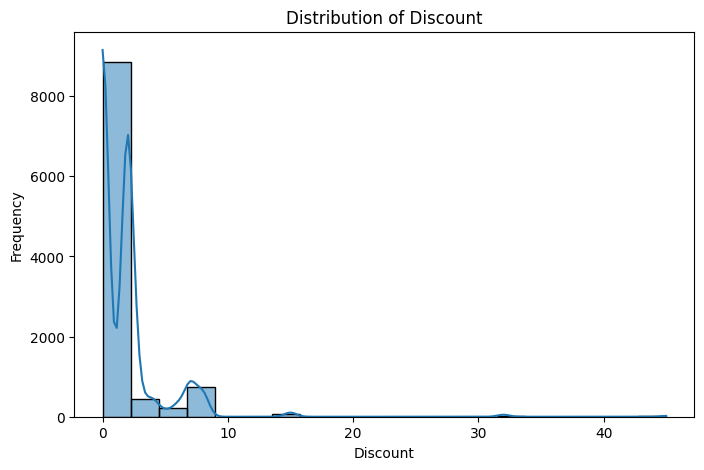

In [43]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Discount'], bins=20, kde=True)
plt.title('Distribution of Discount')
plt.xlabel('Discount')
plt.ylabel('Frequency')
plt.show()

### Relationships Between Numerical Variables (Sales, Quantity, Profit, Discount)

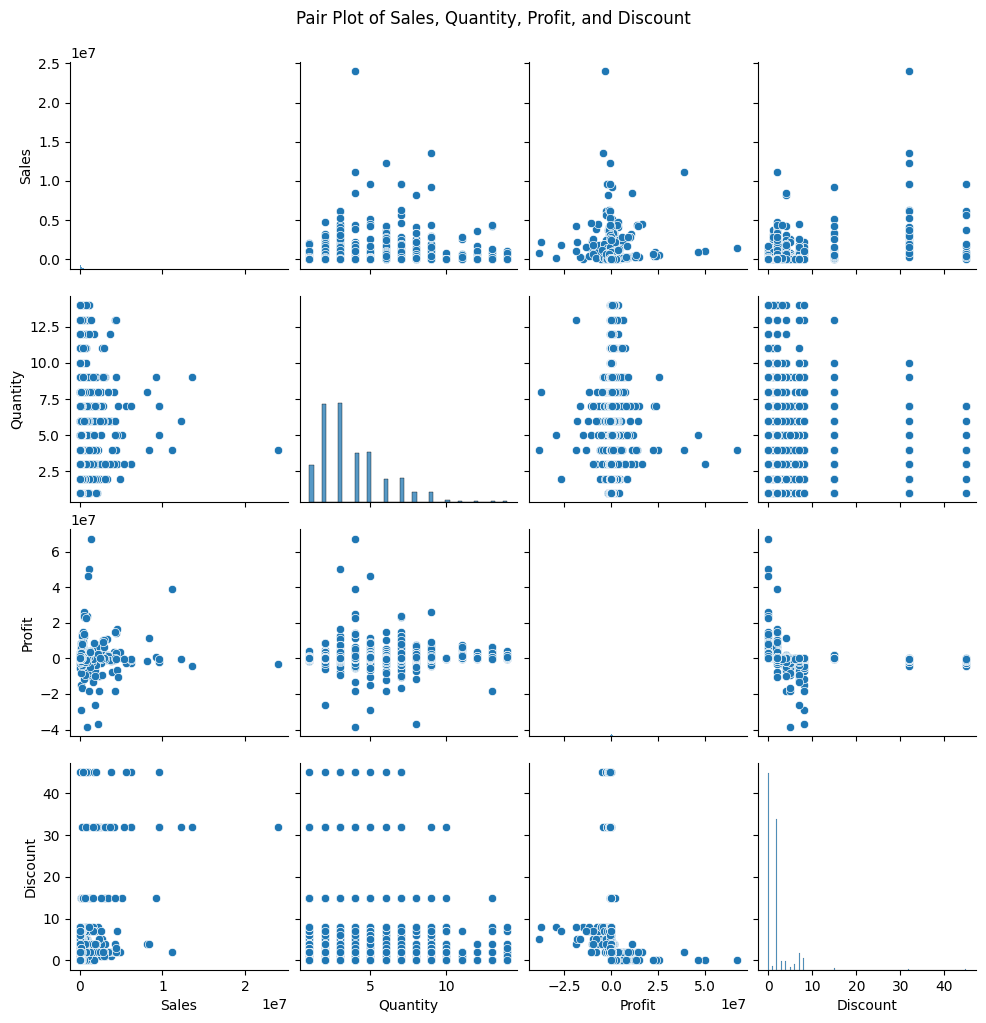

In [44]:
sns.pairplot(df[['Sales', 'Quantity', 'Profit', 'Discount']])
plt.suptitle('Pair Plot of Sales, Quantity, Profit, and Discount', y=1.02)
plt.show()

### Geographical Analysis: Sales and Profit by Region and State

/tmp/ipykernel_2105/515115478.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_region.index, y=sales_by_region.values, palette='coolwarm')


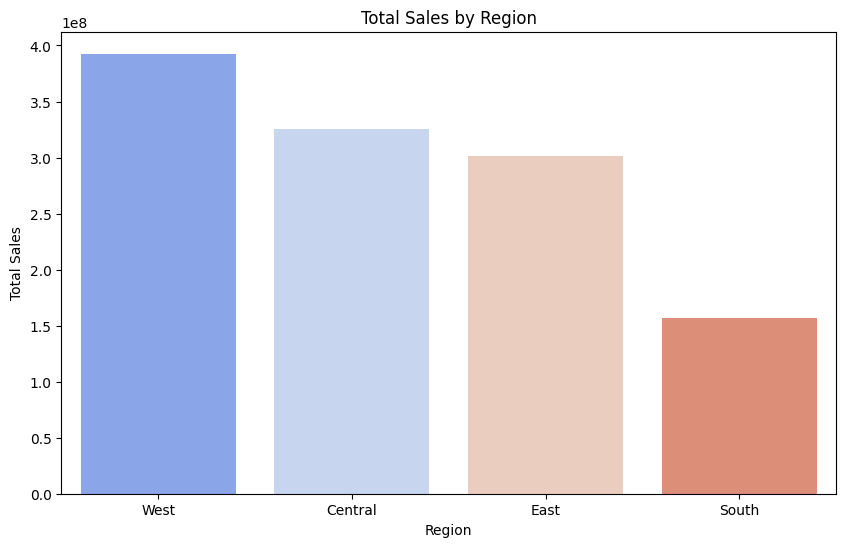

/tmp/ipykernel_2105/515115478.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profit_by_region.index, y=profit_by_region.values, palette='coolwarm')


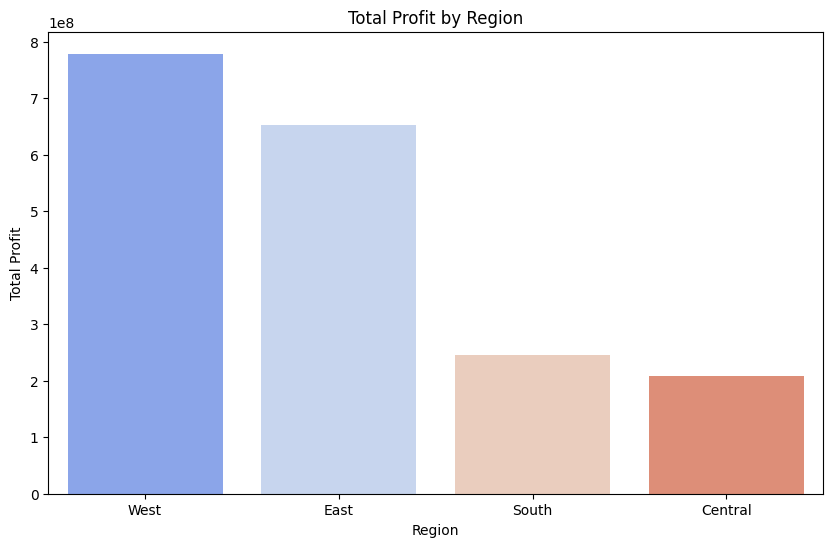

In [51]:
# Merge df with loc_df to get geographical information
df_geo = pd.merge(df, loc_df, on='Postal Code', how='left')

# Sales and Profit by Region
plt.figure(figsize=(10, 6))
sales_by_region = df_geo.groupby('Region')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=sales_by_region.index, y=sales_by_region.values, palette='coolwarm')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.show()

plt.figure(figsize=(10, 6))
profit_by_region = df_geo.groupby('Region')['Profit'].sum().sort_values(ascending=False)
sns.barplot(x=profit_by_region.index, y=profit_by_region.values, palette='coolwarm')
plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.show()

### Analysis by Customer Segment and Ship Mode

/tmp/ipykernel_2105/1620730346.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_geo, x='Segment', y='Sales', estimator=sum, palette='plasma')


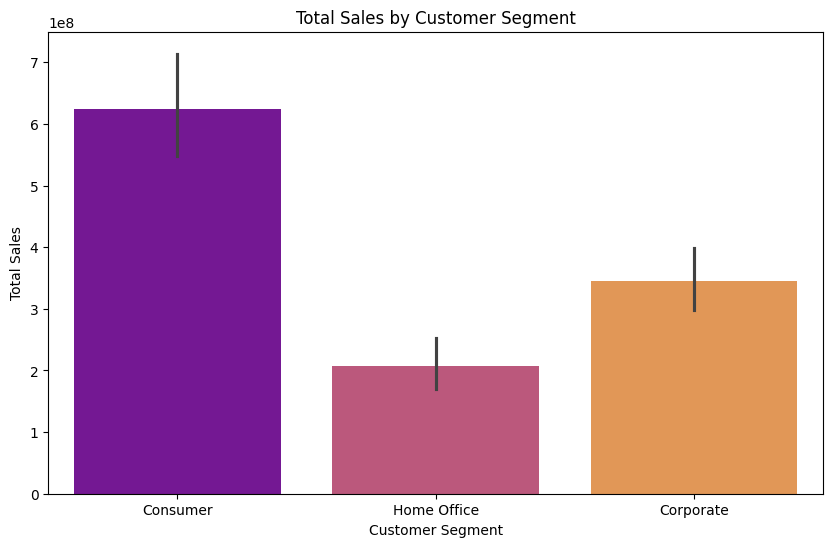

/tmp/ipykernel_2105/1620730346.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_geo, x='Ship Mode', y='Sales', estimator=sum, palette='viridis')


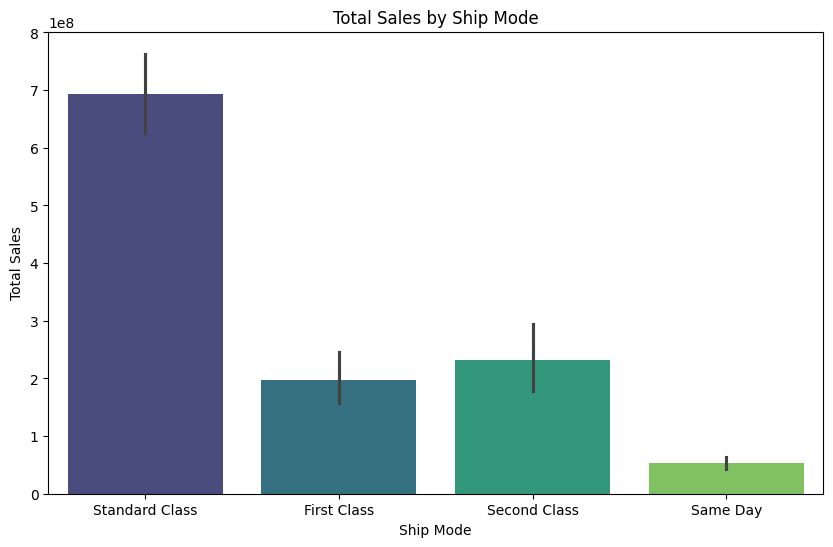

In [52]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_geo, x='Segment', y='Sales', estimator=sum, palette='plasma')
plt.title('Total Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales')
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=df_geo, x='Ship Mode', y='Sales', estimator=sum, palette='viridis')
plt.title('Total Sales by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Total Sales')
plt.show()

### Geographical Analysis: Sales and Profit by Region and State

/tmp/ipykernel_2105/515115478.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_region.index, y=sales_by_region.values, palette='coolwarm')


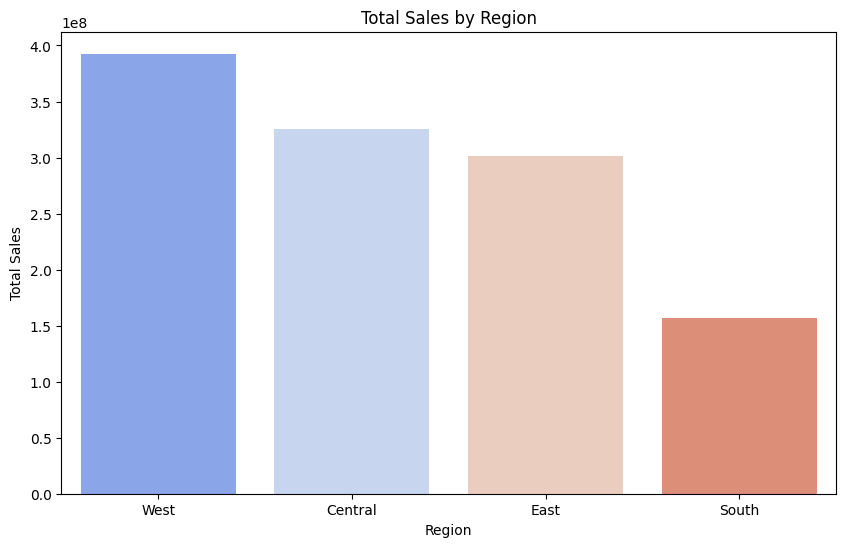

/tmp/ipykernel_2105/515115478.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profit_by_region.index, y=profit_by_region.values, palette='coolwarm')


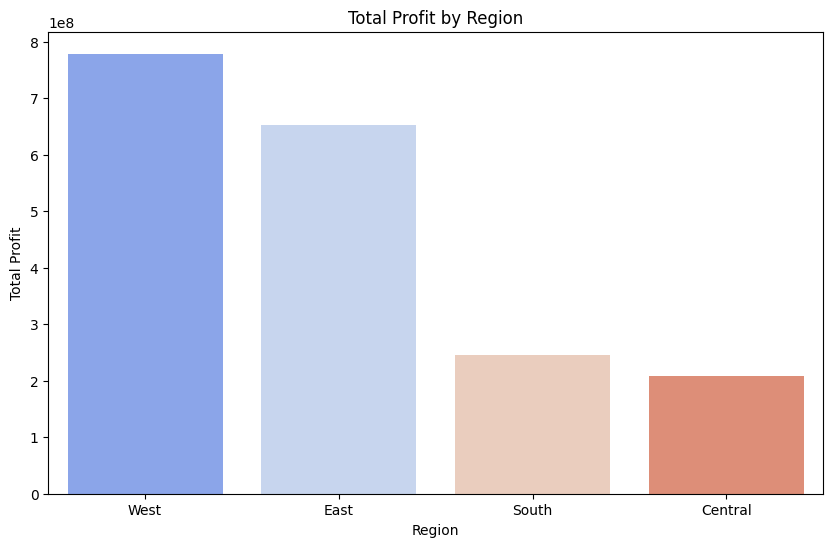

In [49]:
# Merge df with loc_df to get geographical information
df_geo = pd.merge(df, loc_df, on='Postal Code', how='left')

# Sales and Profit by Region
plt.figure(figsize=(10, 6))
sales_by_region = df_geo.groupby('Region')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=sales_by_region.index, y=sales_by_region.values, palette='coolwarm')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.show()

plt.figure(figsize=(10, 6))
profit_by_region = df_geo.groupby('Region')['Profit'].sum().sort_values(ascending=False)
sns.barplot(x=profit_by_region.index, y=profit_by_region.values, palette='coolwarm')
plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.show()

### Analysis by Customer Segment and Ship Mode

/tmp/ipykernel_2105/1620730346.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_geo, x='Segment', y='Sales', estimator=sum, palette='plasma')


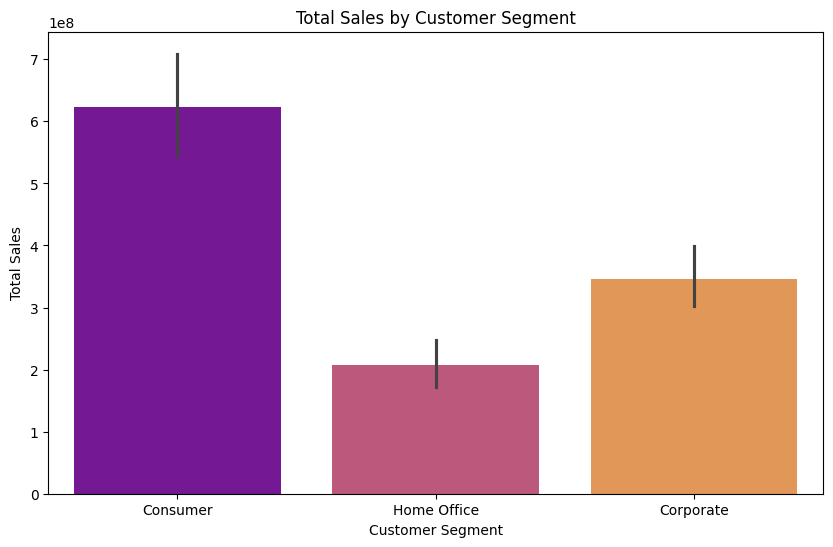

/tmp/ipykernel_2105/1620730346.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_geo, x='Ship Mode', y='Sales', estimator=sum, palette='viridis')


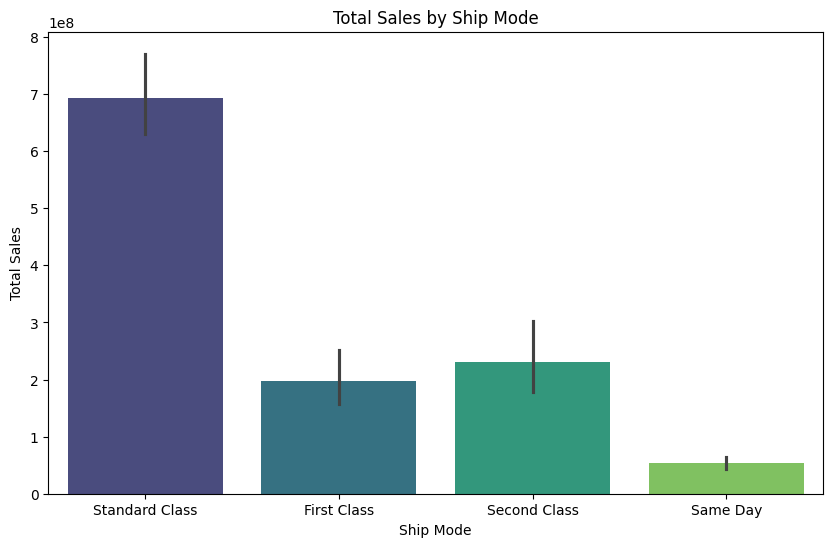

In [50]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_geo, x='Segment', y='Sales', estimator=sum, palette='plasma')
plt.title('Total Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales')
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=df_geo, x='Ship Mode', y='Sales', estimator=sum, palette='viridis')
plt.title('Total Sales by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Total Sales')
plt.show()

### Geographical Analysis: Sales and Profit by Region and State

/tmp/ipykernel_2105/515115478.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_region.index, y=sales_by_region.values, palette='coolwarm')


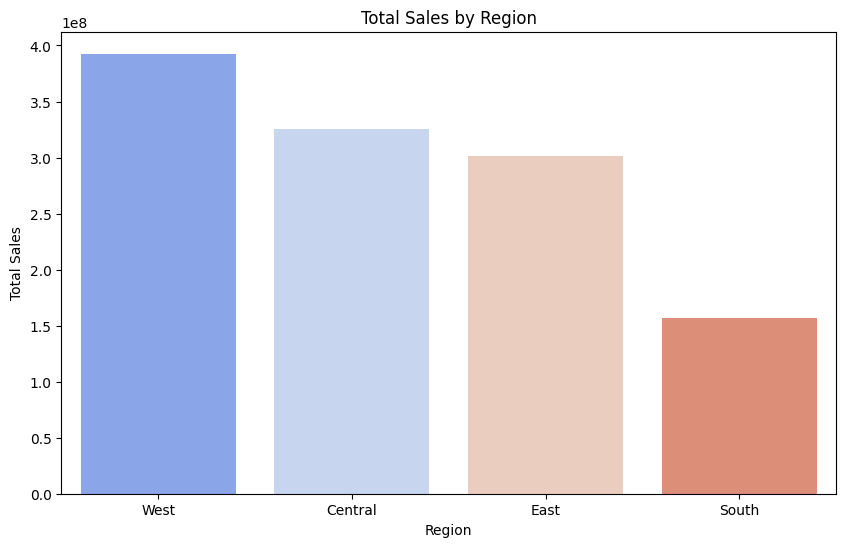

/tmp/ipykernel_2105/515115478.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profit_by_region.index, y=profit_by_region.values, palette='coolwarm')


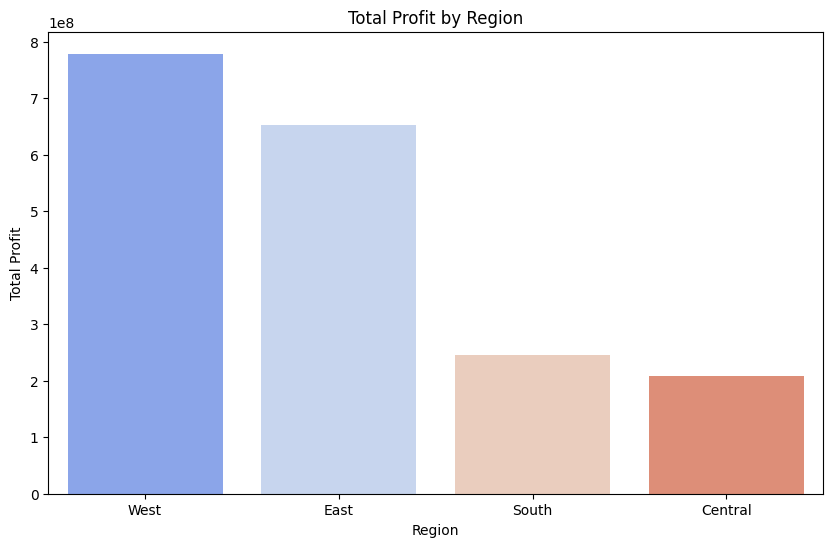

In [47]:
# Merge df with loc_df to get geographical information
df_geo = pd.merge(df, loc_df, on='Postal Code', how='left')

# Sales and Profit by Region
plt.figure(figsize=(10, 6))
sales_by_region = df_geo.groupby('Region')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=sales_by_region.index, y=sales_by_region.values, palette='coolwarm')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.show()

plt.figure(figsize=(10, 6))
profit_by_region = df_geo.groupby('Region')['Profit'].sum().sort_values(ascending=False)
sns.barplot(x=profit_by_region.index, y=profit_by_region.values, palette='coolwarm')
plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.show()

### Analysis by Customer Segment and Ship Mode

/tmp/ipykernel_2105/1620730346.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_geo, x='Segment', y='Sales', estimator=sum, palette='plasma')


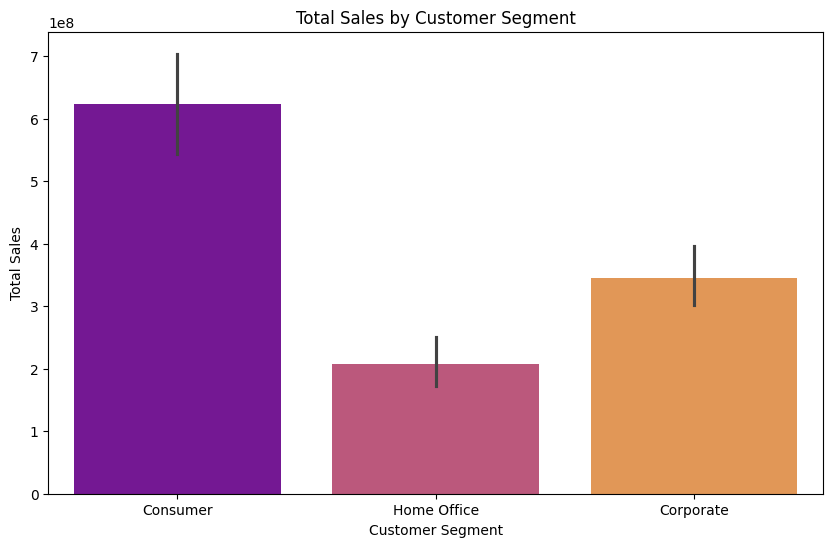

/tmp/ipykernel_2105/1620730346.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_geo, x='Ship Mode', y='Sales', estimator=sum, palette='viridis')


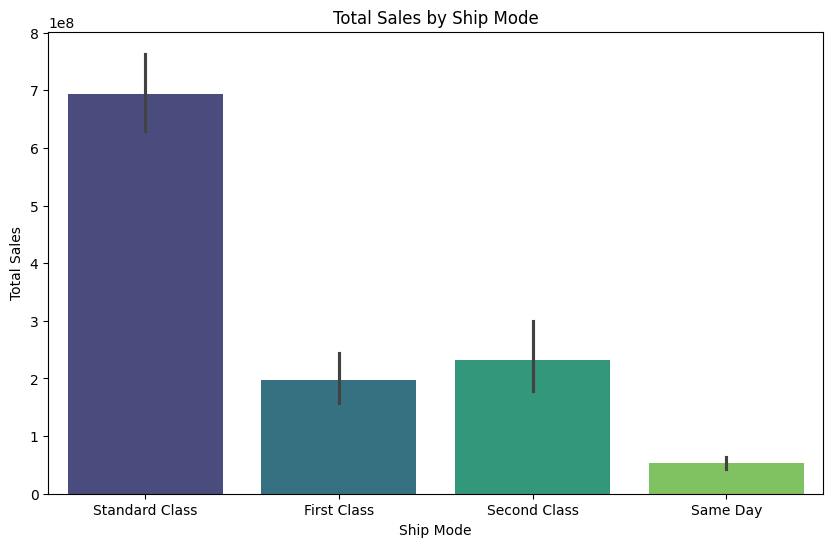

In [48]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_geo, x='Segment', y='Sales', estimator=sum, palette='plasma')
plt.title('Total Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales')
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=df_geo, x='Ship Mode', y='Sales', estimator=sum, palette='viridis')
plt.title('Total Sales by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Total Sales')
plt.show()

### Temporal Analysis: Sales and Profit Over Time

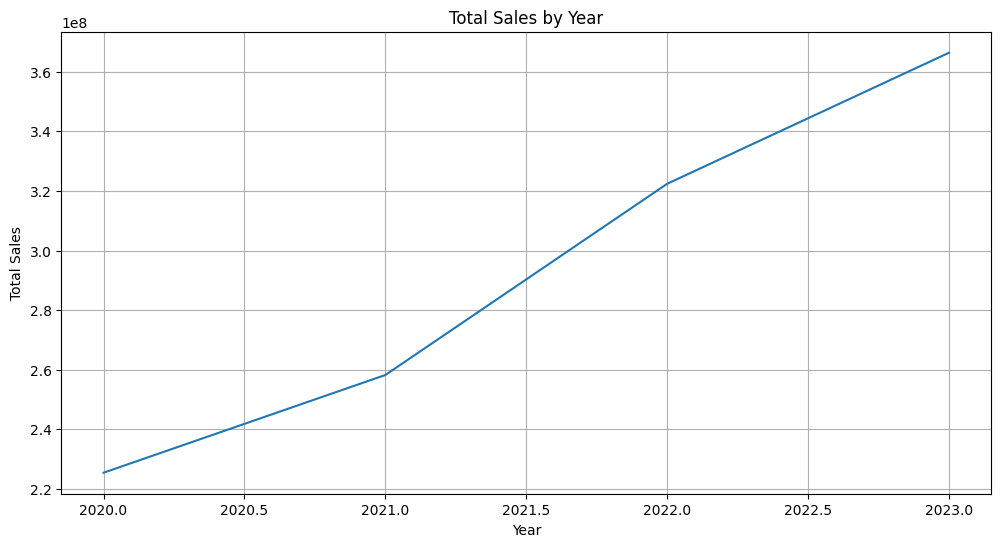

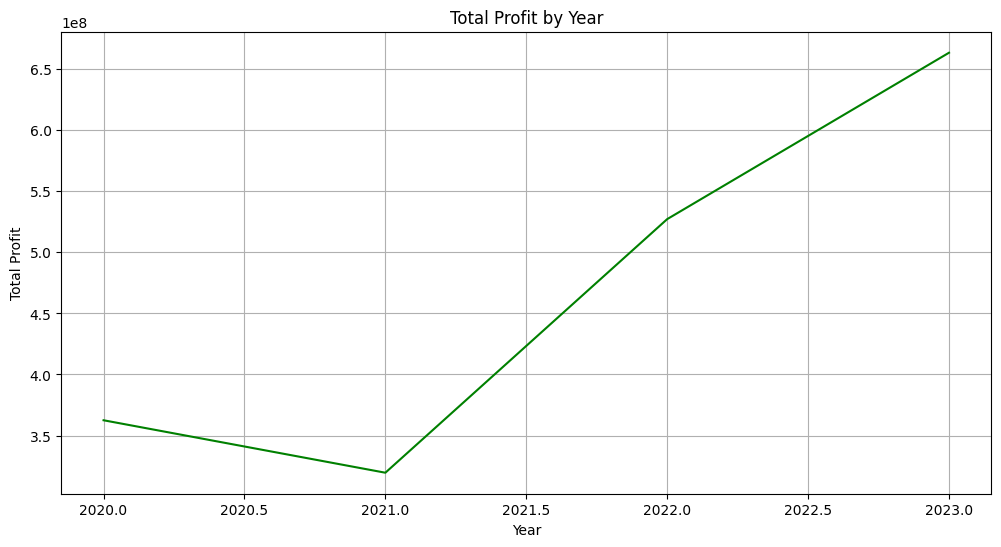

In [45]:
plt.figure(figsize=(12, 6))
sales_by_year = df.groupby('Order Year')['Sales'].sum()
sns.lineplot(x=sales_by_year.index, y=sales_by_year.values)
plt.title('Total Sales by Year')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
profit_by_year = df.groupby('Order Year')['Profit'].sum()
sns.lineplot(x=profit_by_year.index, y=profit_by_year.values, color='green')
plt.title('Total Profit by Year')
plt.xlabel('Year')
plt.ylabel('Total Profit')
plt.grid(True)
plt.show()

<Figure size 1500x700 with 0 Axes>

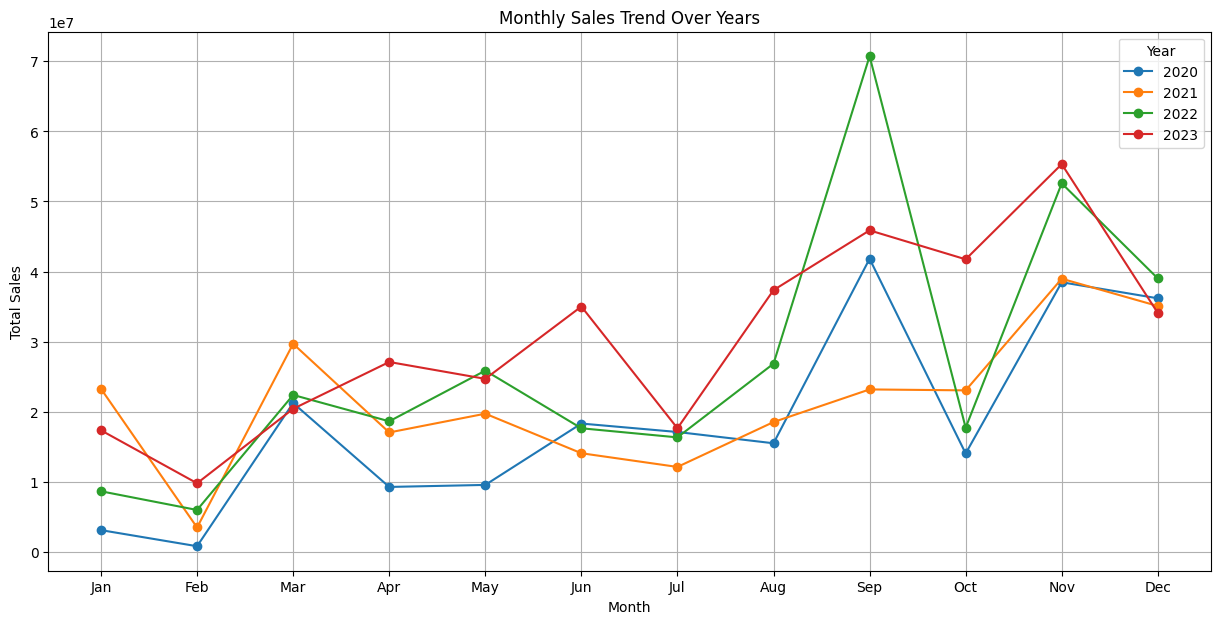

<Figure size 1500x700 with 0 Axes>

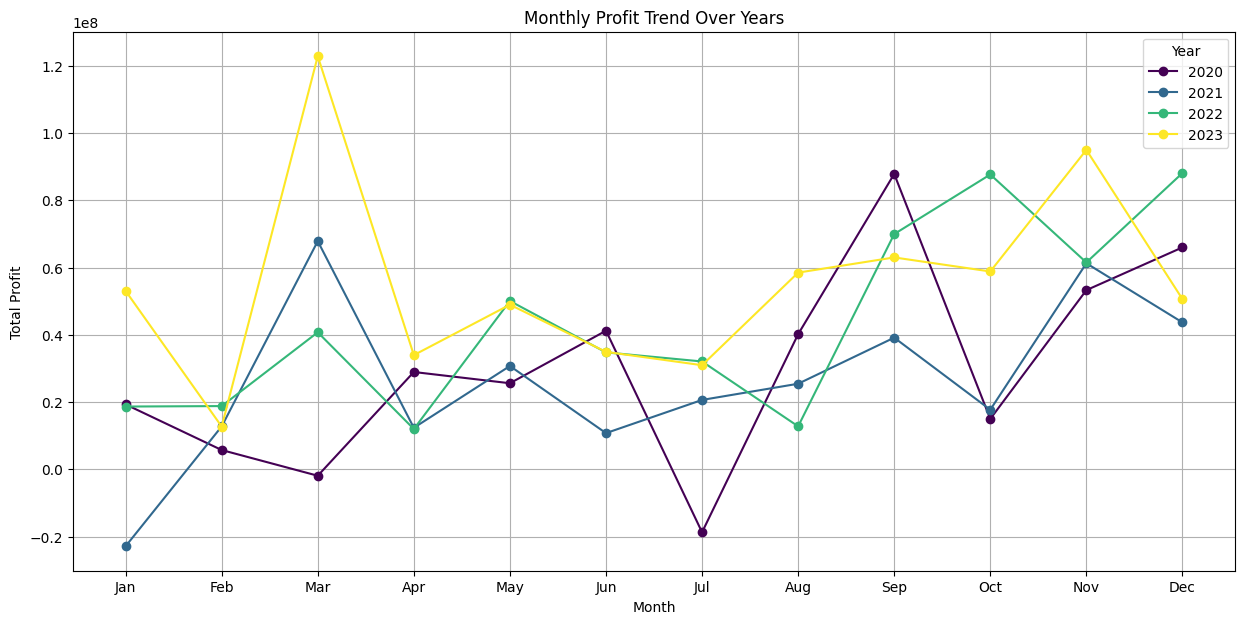

In [46]:
plt.figure(figsize=(15, 7))
sales_by_month = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().unstack(level=0)
sales_by_month.plot(kind='line', marker='o', figsize=(15, 7))
plt.title('Monthly Sales Trend Over Years')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.legend(title='Year')
plt.show()

plt.figure(figsize=(15, 7))
profit_by_month = df.groupby(['Order Year', 'Order Month'])['Profit'].sum().unstack(level=0)
profit_by_month.plot(kind='line', marker='o', figsize=(15, 7), colormap='viridis')
plt.title('Monthly Profit Trend Over Years')
plt.xlabel('Month')
plt.ylabel('Total Profit')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.legend(title='Year')
plt.show()

In [40]:
df['Discount'] = df['Discount'].astype('float')

### Distribution of Categorical Variables

/tmp/ipykernel_2105/4268242301.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Category', palette='viridis')


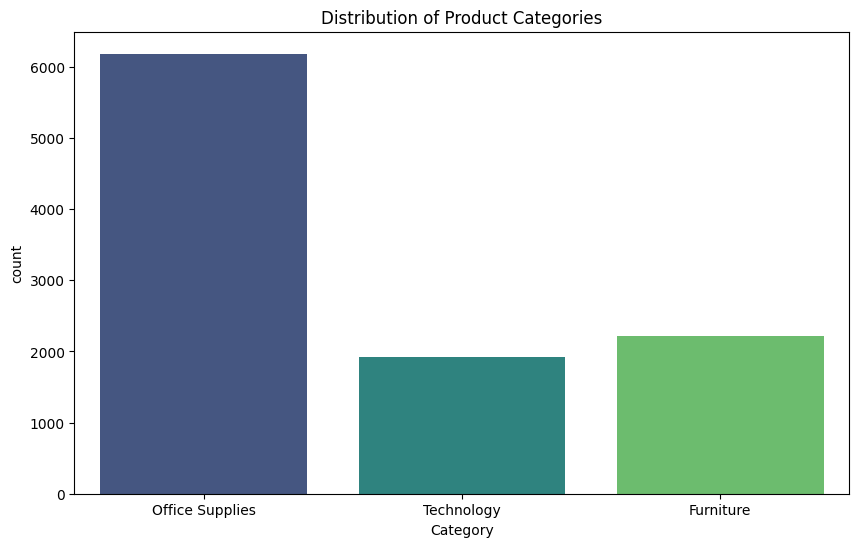

/tmp/ipykernel_2105/4268242301.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sub-Category', palette='magma')


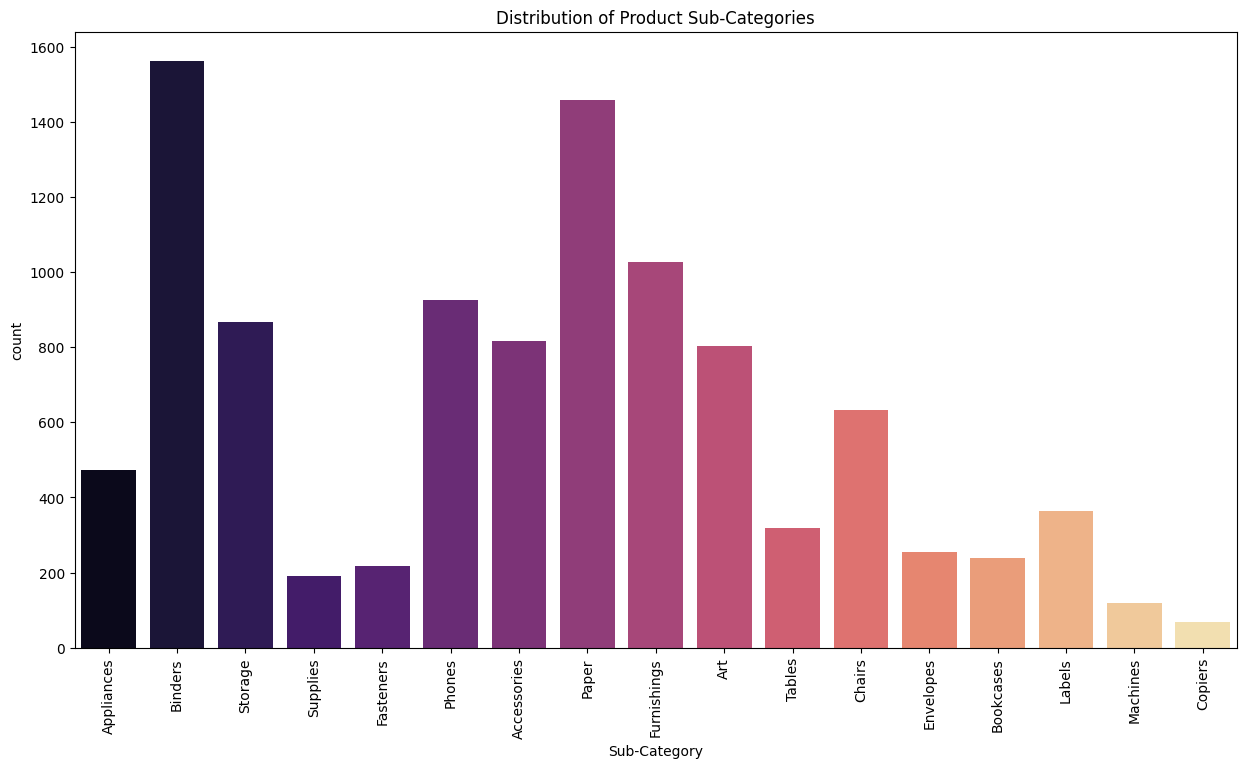

In [41]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Category', palette='viridis')
plt.title('Distribution of Product Categories')
plt.show()

plt.figure(figsize=(15, 8))
sns.countplot(data=df, x='Sub-Category', palette='magma')
plt.title('Distribution of Product Sub-Categories')
plt.xticks(rotation=90)
plt.show()